# Exploratory Data Analysis: Digital Addiction Prediction

**Goal:** Explore screen-time / device-usage behavioral data to understand patterns and relationships
that will inform **feature engineering** and a downstream **machine learning classifier** for the
target column `addicted_label` (0 = not addicted, 1 = addicted).

This notebook is organized to answer the questions that matter most before modeling:

1. What does the data look like structurally (types, size, duplicates)?
2. How much data is missing, where, and does missingness itself relate to the target?
3. What do individual features look like (distributions, outliers, skew)?
4. How does each feature relate to the target (the signal we actually care about)?
5. How do features relate to *each other* (redundancy / multicollinearity)?
6. What derived / engineered features look promising?
7. What are the actionable takeaways for preprocessing and modeling?

> **Note on the data used here:** This notebook ships with a small 7-row sample (`sample_data.csv`)
> that mirrors the exact schema you provided, so the whole pipeline runs end-to-end out of the box.
> With only 7 rows, most plots will look sparse and statistics will be unstable — that's expected.
> **Change `DATA_PATH` below to point at your full dataset** to get meaningful insights. Every cell
> is written generically (no hard-coded row counts or values) so it will scale to your real data
> without modification.


## 1. Setup & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ---- Display / plotting configuration ----
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

import warnings
warnings.filterwarnings("ignore")

# ---- Point this at your real dataset ----
DATA_PATH = "sample_data.csv"   # <-- change to your full CSV, e.g. "addiction_data.csv"
TARGET = "addicted_label"
ID_COL = "id"

RANDOM_STATE = 42


## 2. Load Data & First Look

In [2]:
df_raw = pd.read_csv("data/train.csv")
df = df_raw.copy()
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head(10)


Shape: 691369 rows x 14 columns


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
5,5,28.0,7.37,1.78,1.56,3.38,8.33,210.0,40.0,7.85,Male,High,No,0
6,6,18.0,4.24,1.61,1.14,0.91,5.09,220.0,68.0,7.46,Other,Low,Yes,0
7,7,25.0,10.79,3.92,2.48,3.61,7.20,195.0,NaN,13.45,Other,High,No,1
8,8,26.0,8.42,2.57,3.41,1.90,6.64,99.0,27.0,8.35,Other,Medium,Yes,0
9,9,20.0,8.74,1.40,2.43,2.11,8.57,NaN,109.0,10.68,Other,High,NaN,1


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  str    
 11  stress_level             636221 non-null  str    
 12  academic_work_impact     647145 non-null  str    
 13  addicted_label           691369 non-null  int64  
dtypes: float64(9), 

**What to check here:** row/column counts, dtypes matching expectation (numeric columns
should not be read as `object`), and an early sense of which columns have missing values
(`non-null` counts below the total row count).

## 3. Data Quality Checks

Before analyzing patterns, rule out basic data issues: duplicate rows, a non-informative ID
column, invalid/out-of-range values, and inconsistent category labels.

In [4]:
# Duplicate rows (excluding id, which is unique by construction)
feature_cols_for_dupe_check = [c for c in df.columns if c != ID_COL]
n_dupes = df.duplicated(subset=feature_cols_for_dupe_check).sum()
print(f"Fully duplicated rows (ignoring id): {n_dupes}")

# Duplicate ids
if ID_COL in df.columns:
    print(f"Duplicate ids: {df[ID_COL].duplicated().sum()}")


Fully duplicated rows (ignoring id): 0
Duplicate ids: 0


In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if ID_COL in numeric_cols:
    numeric_cols.remove(ID_COL)
if TARGET in numeric_cols:
    numeric_cols.remove(TARGET)

categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric feature columns:", numeric_cols)
print("Categorical feature columns:", categorical_cols)


Numeric feature columns: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
Categorical feature columns: ['gender', 'stress_level', 'academic_work_impact']


In [6]:
# Sanity-check numeric ranges (flag impossible values: negatives, absurd hours, etc.)
range_summary = df[numeric_cols].agg(["min", "max", "mean"]).T
range_summary["negative_values"] = (df[numeric_cols] < 0).sum()
range_summary


,min,max,mean,negative_values
age,18.00,35.00,26.615408,0
daily_screen_time_hours,0.50,15.00,7.640865,0
social_media_hours,0.00,8.00,2.471038,0
gaming_hours,0.00,4.00,1.459265,0
work_study_hours,0.00,6.00,2.366971,0
sleep_hours,4.50,9.00,6.804334,0
notifications_per_day,20.00,250.00,145.894900,0
app_opens_per_day,15.00,180.00,102.636781,0
weekend_screen_time,0.51,17.56,9.479866,0


In [7]:
# Consistency check: sleep + daily_screen_time shouldn't exceed 24h in a day (loose sanity bound)
if {"sleep_hours", "daily_screen_time_hours"}.issubset(df.columns):
    over_24 = df[(df["sleep_hours"] + df["daily_screen_time_hours"]) > 24]
    print(f"Rows where sleep_hours + daily_screen_time_hours > 24: {len(over_24)}")

# Consistency check: sub-components (social_media + gaming + work_study) vs daily_screen_time_hours
sub_components = ["social_media_hours", "gaming_hours", "work_study_hours"]
if set(sub_components).issubset(df.columns) and "daily_screen_time_hours" in df.columns:
    implied_total = df[sub_components].sum(axis=1, skipna=True)
    diff = df["daily_screen_time_hours"] - implied_total
    print("Difference between reported daily_screen_time_hours and sum of sub-activities:")
    print(diff.describe())


Rows where sleep_hours + daily_screen_time_hours > 24: 0
Difference between reported daily_screen_time_hours and sum of sub-activities:
count    595515.000000
mean          2.115226
std           2.141970
min           0.000000
25%           0.560000
50%           1.130000
75%           3.170000
max          14.810000
dtype: float64


**Feature engineering signal:** the difference between `daily_screen_time_hours` and the sum
of its sub-activities (social media + gaming + work/study) captures "other" unaccounted screen
time (e.g. browsing, messaging, video). This gap itself may be predictive and is a strong
candidate engineered feature (`unaccounted_screen_time`).

## 4. Missing Value Analysis

Understanding *how much* is missing and *where* determines imputation strategy. Just as
importantly, we check whether missingness **correlates with the target** — if addicted users
are more/less likely to skip a question, missingness itself is a signal and "is_missing"
indicator features may be worth engineering.

In [8]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_pct", ascending=False)
missing_summary


,missing_count,missing_pct
social_media_hours,133995,19.38
gaming_hours,126821,18.34
weekend_screen_time,112063,16.21
daily_screen_time_hours,95854,13.86
app_opens_per_day,80710,11.67
notifications_per_day,67584,9.78
stress_level,55148,7.98
work_study_hours,51518,7.45
sleep_hours,44480,6.43
academic_work_impact,44224,6.40


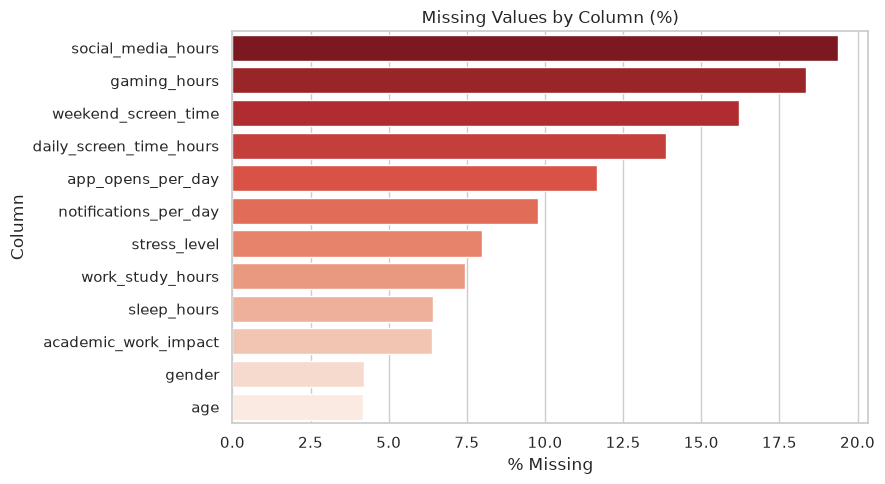

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
if not missing_summary.empty:
    sns.barplot(x=missing_summary["missing_pct"], y=missing_summary.index, ax=ax, palette="Reds_r")
    ax.set_xlabel("% Missing")
    ax.set_ylabel("Column")
    ax.set_title("Missing Values by Column (%)")
else:
    ax.text(0.5, 0.5, "No missing values found", ha="center", va="center")
plt.tight_layout()
plt.show()


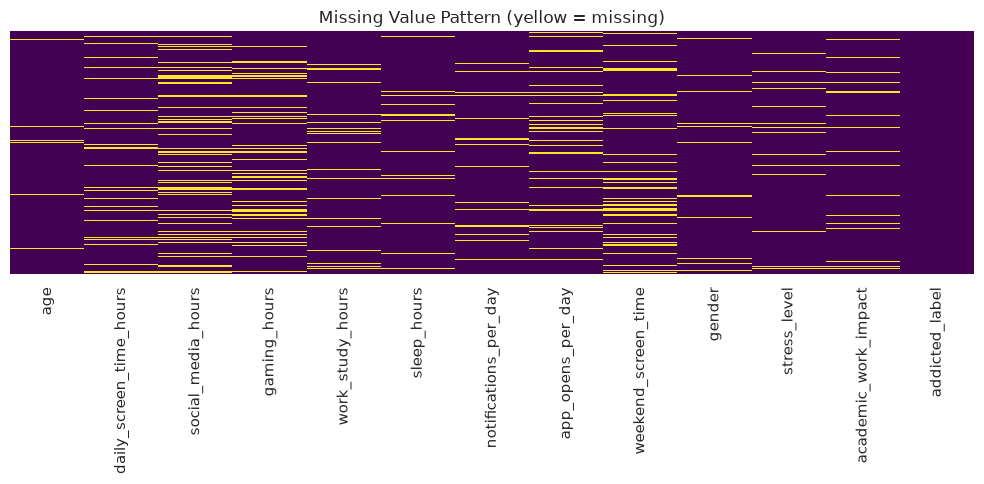

In [10]:
# Visual missingness pattern (heatmap): helps spot whether missingness is random
# or clustered in specific rows/columns
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df.drop(columns=[ID_COL], errors="ignore").isnull(), cbar=False,
            cmap="viridis", yticklabels=False, ax=ax)
ax.set_title("Missing Value Pattern (yellow = missing)")
plt.tight_layout()
plt.show()


In [11]:
# Does missingness relate to the target? For each column with missing values,
# compare the addicted_label rate when the value IS missing vs NOT missing.
rows = []
for col in missing_summary.index:
    is_missing = df[col].isnull()
    if is_missing.sum() > 0 and (~is_missing).sum() > 0:
        rate_missing = df.loc[is_missing, TARGET].mean()
        rate_present = df.loc[~is_missing, TARGET].mean()
        rows.append({
            "column": col,
            "addicted_rate_when_missing": rate_missing,
            "addicted_rate_when_present": rate_present,
            "difference": rate_missing - rate_present,
        })
missingness_vs_target = pd.DataFrame(rows).sort_values("difference", key=abs, ascending=False)
missingness_vs_target


,column,addicted_rate_when_missing,addicted_rate_when_present,difference
8,sleep_hours,0.713377,0.709153,0.004224
11,age,0.713402,0.709251,0.004151
4,app_opens_per_day,0.712787,0.708980,0.003807
3,daily_screen_time_hours,0.711301,0.709122,0.002178
2,weekend_screen_time,0.710654,0.709187,0.001467
1,gaming_hours,0.710505,0.709182,0.001324
7,work_study_hours,0.710645,0.709326,0.001319
5,notifications_per_day,0.710242,0.709336,0.000906
10,gender,0.708790,0.709452,-0.000662
6,stress_level,0.709001,0.709461,-0.000460


**How to read this:** a large `difference` for a column means whether that field was
answered/recorded is itself associated with the target. If confirmed on the full dataset, add a
binary `<column>_was_missing` indicator feature rather than only imputing the value — the
imputation would otherwise erase that signal.

## 5. Target Variable (`addicted_label`) Analysis

Checking class balance first, since it determines evaluation metric choice (accuracy vs.
precision/recall/F1/ROC-AUC) and whether resampling (SMOTE, class weights) will be needed.

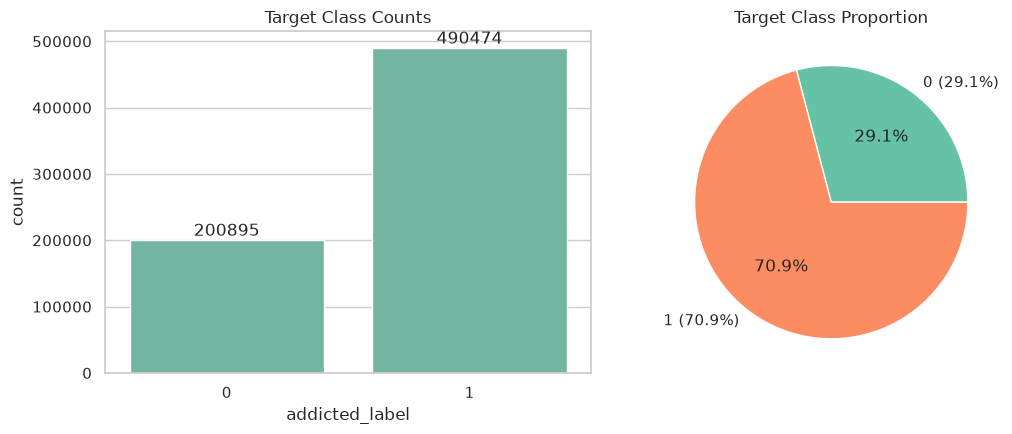

addicted_label
0    200895
1    490474
Name: count, dtype: int64
addicted_label
0    29.1
1    70.9
Name: proportion, dtype: float64


In [12]:
target_counts = df[TARGET].value_counts().sort_index()
target_pct = (df[TARGET].value_counts(normalize=True) * 100).round(1).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.countplot(x=df[TARGET], ax=axes[0])
axes[0].set_title("Target Class Counts")
axes[0].set_xlabel("addicted_label")
for i, v in enumerate(target_counts):
    axes[0].text(i, v, str(v), ha="center", va="bottom")

axes[1].pie(target_pct, labels=[f"{i} ({p}%)" for i, p in zip(target_pct.index, target_pct)],
            autopct="%1.1f%%", colors=sns.color_palette("Set2"))
axes[1].set_title("Target Class Proportion")
plt.tight_layout()
plt.show()

print(target_counts)
print(target_pct)


**Modeling implication:** if one class dominates (e.g. >70/30 split), plan to use
stratified train/test splits, class-weighted loss, or resampling, and prefer ROC-AUC / F1 /
balanced accuracy over raw accuracy for evaluation.

## 6. Numeric Feature Distributions

Histogram + KDE for every numeric feature to check skew, multi-modality, and plausible ranges —
this informs whether to apply transforms (log, Box-Cox) or scaling (standardization vs. robust
scaling for skewed/outlier-heavy features).

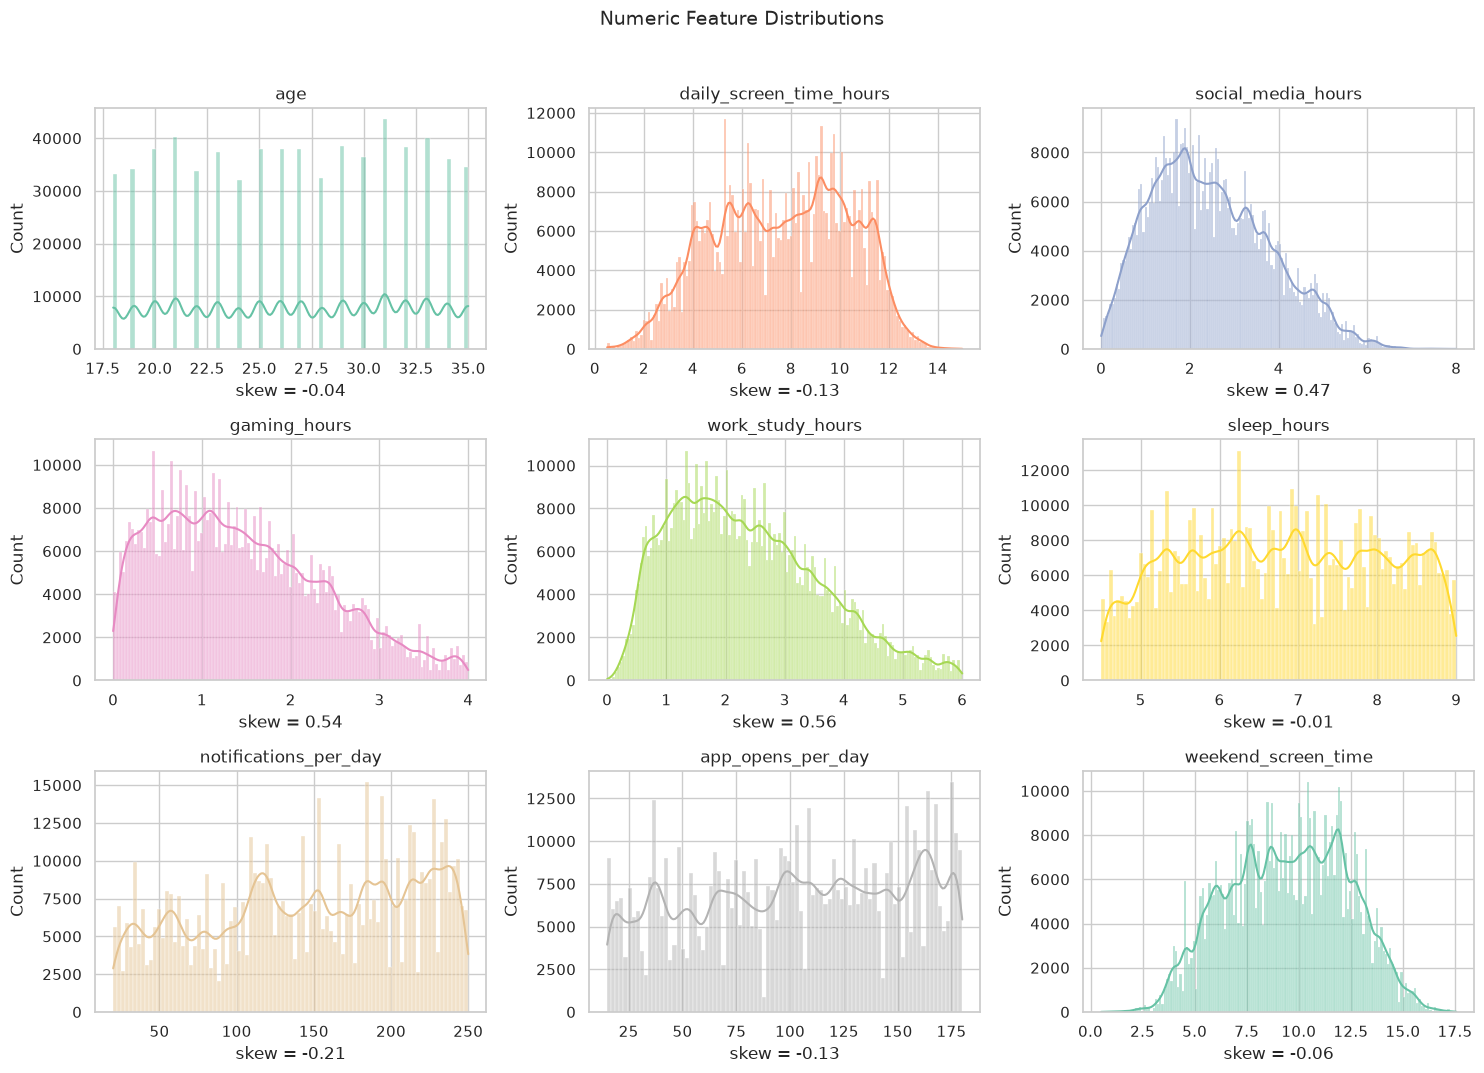

In [ ]:
###### MY WORK #######

# df["social_media_hours"] = df["social_media_hours"] ** 0.5
# df["social_media_hours"] = df["social_media_hours"] ** 0.5
# df["social_media_hours"] = df["social_media_hours"] ** 0.5

######################

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color=sns.color_palette("Set2")[i % 8])
    axes[i].set_title(col)
    skew = df[col].skew()
    axes[i].set_xlabel(f"skew = {skew:.2f}")

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Numeric Feature Distributions", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


In [14]:
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


## 7. Outlier Detection (Boxplots + IQR)

Outliers can be legitimate "heavy user" behavior (informative!) or data entry errors — the
boxplots plus an explicit IQR flag table let you distinguish plausible extreme usage from
likely mistakes before deciding whether to cap/winsorize or leave values as-is.

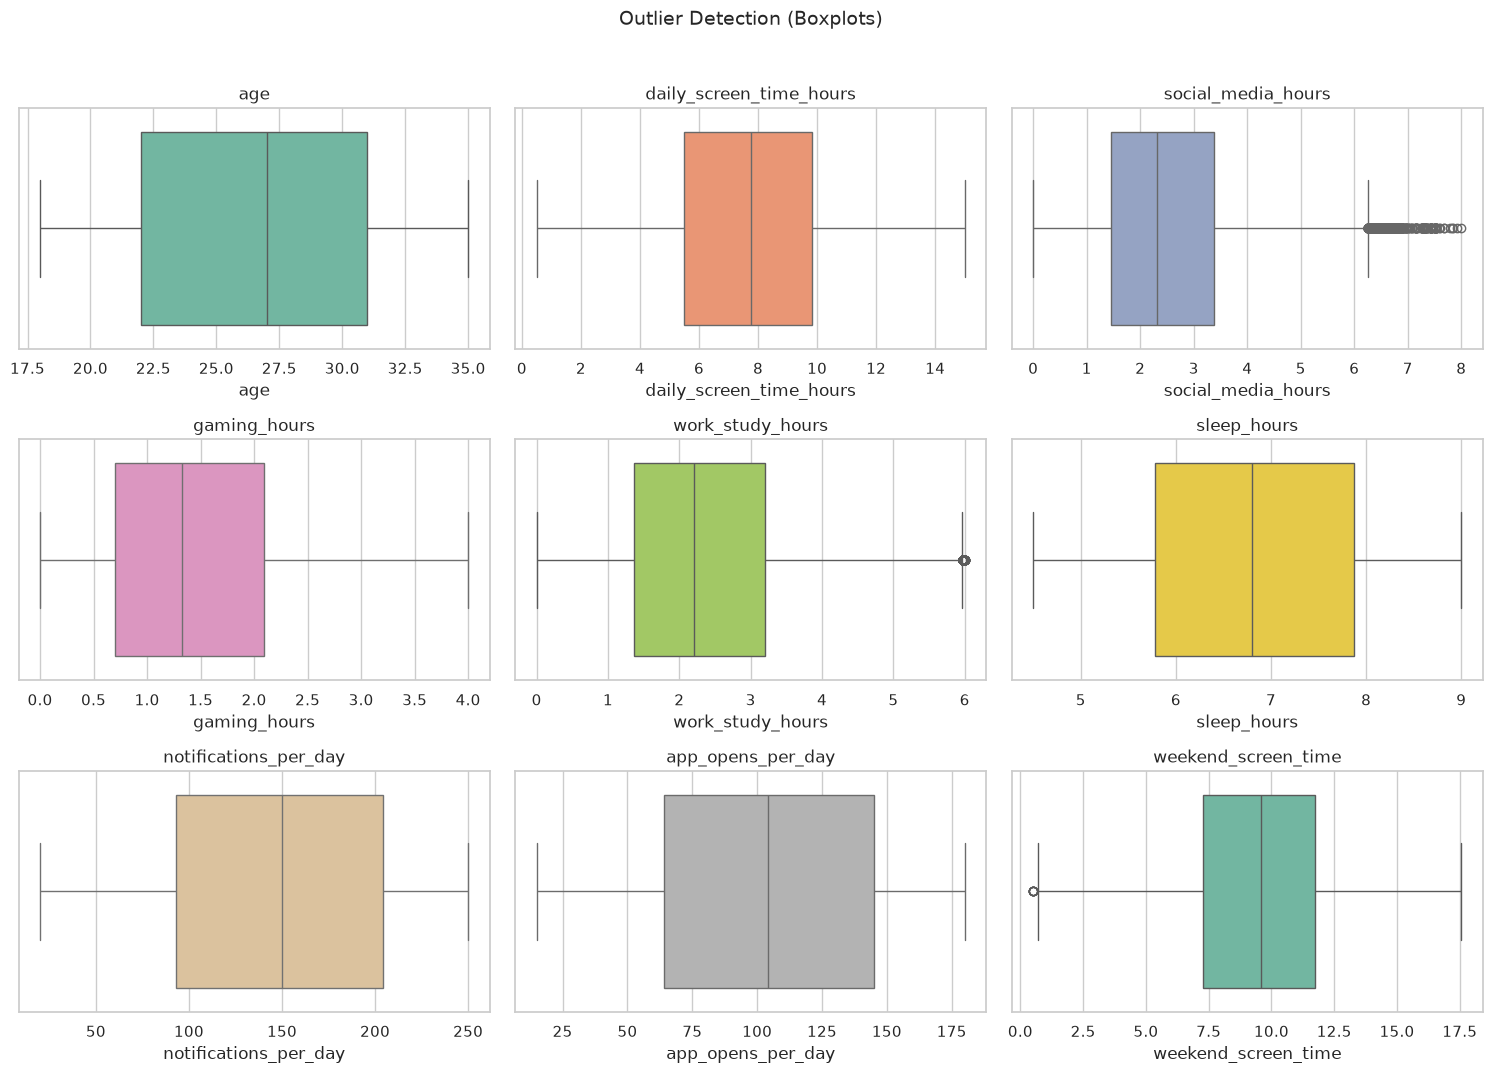

In [15]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color=sns.color_palette("Set2")[i % 8])
    axes[i].set_title(col)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Outlier Detection (Boxplots)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


In [16]:
outlier_rows = []
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append({"column": col, "lower_bound": round(lower, 2), "upper_bound": round(upper, 2),
                          "n_outliers": n_outliers, "pct_outliers": round(n_outliers / len(df) * 100, 2)})
outlier_summary = pd.DataFrame(outlier_rows).sort_values("pct_outliers", ascending=False)
outlier_summary


,column,lower_bound,upper_bound,n_outliers,pct_outliers
2,social_media_hours,-1.43,6.25,1209,0.17
4,work_study_hours,-1.40,5.96,300,0.04
0,age,8.50,44.50,0,0.00
1,daily_screen_time_hours,-1.06,16.38,0,0.00
3,gaming_hours,-1.39,4.17,0,0.00
5,sleep_hours,2.65,11.00,0,0.00
6,notifications_per_day,-73.50,370.50,0,0.00
7,app_opens_per_day,-57.50,266.50,0,0.00
8,weekend_screen_time,0.58,18.45,6,0.00


## 8. Categorical Feature Distributions

`gender`, `stress_level`, and `academic_work_impact` need encoding decisions before modeling
(one-hot for nominal `gender`, ordinal encoding for `stress_level` since Low < Medium < High).
First, see how balanced each category is.

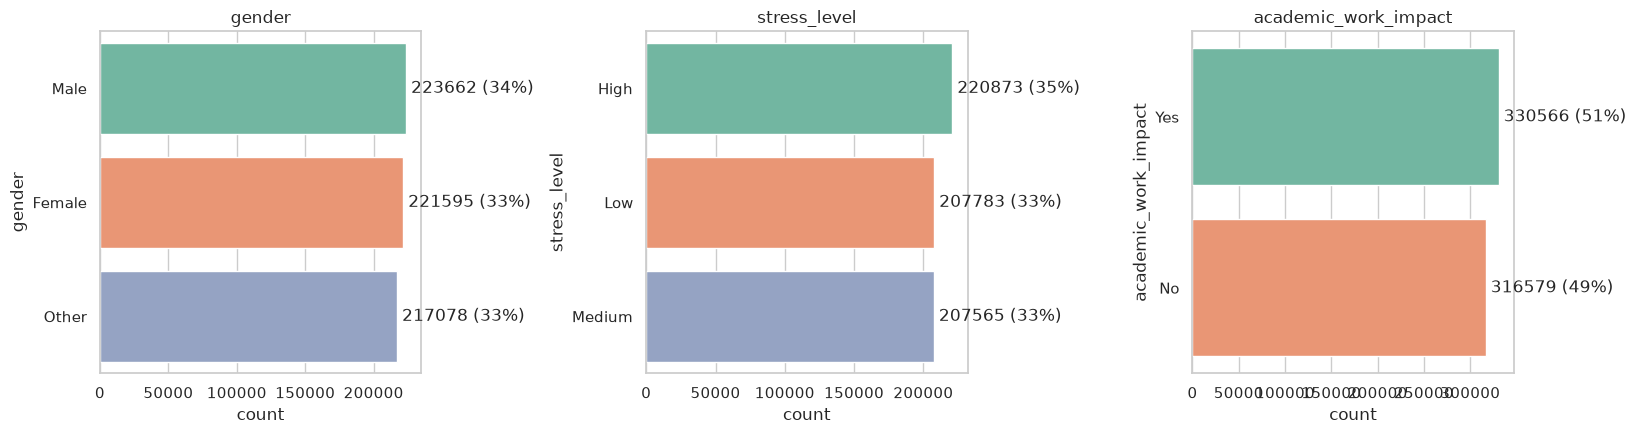

In [17]:
fig, axes = plt.subplots(1, len(categorical_cols), figsize=(5.5 * len(categorical_cols), 4.5))
if len(categorical_cols) == 1:
    axes = [axes]

for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=axes[i], palette="Set2")
    axes[i].set_title(col)
    total = df[col].notnull().sum()
    for p in axes[i].patches:
        width = p.get_width()
        axes[i].text(width, p.get_y() + p.get_height() / 2,
                     f" {width:.0f} ({width/total*100:.0f}%)", va="center")

plt.tight_layout()
plt.show()


## 9. Categorical Features vs. Target

The addiction rate *within* each category is more informative than raw counts — a category with
a much higher/lower addiction rate than the overall average is a strong candidate signal for the
model (and for one-hot / ordinal encoding choices).

Overall addiction rate: 70.94%


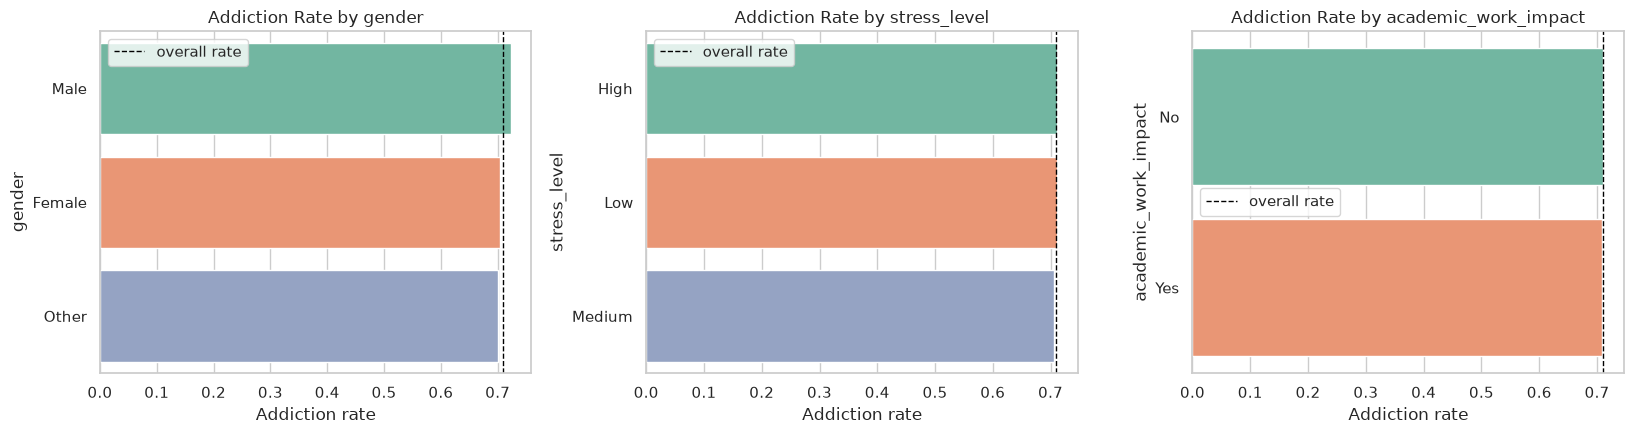

In [18]:
overall_rate = df[TARGET].mean()
print(f"Overall addiction rate: {overall_rate:.2%}")

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(5.5 * len(categorical_cols), 4.5))
if len(categorical_cols) == 1:
    axes = [axes]

for i, col in enumerate(categorical_cols):
    rate_by_cat = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    sns.barplot(x=rate_by_cat.values, y=rate_by_cat.index, ax=axes[i], palette="Set2")
    axes[i].axvline(overall_rate, color="black", linestyle="--", linewidth=1, label="overall rate")
    axes[i].set_xlabel("Addiction rate")
    axes[i].set_title(f"Addiction Rate by {col}")
    axes[i].legend()

plt.tight_layout()
plt.show()


In [19]:
# Crosstab counts + normalized proportions for each categorical feature
for col in categorical_cols:
    print(f"\n--- {col} vs {TARGET} ---")
    ct = pd.crosstab(df[col], df[TARGET], margins=True)
    ct_norm = pd.crosstab(df[col], df[TARGET], normalize="index").round(3)
    display(ct)
    display(ct_norm)



--- gender vs addicted_label ---


addicted_label,0,1,All
gender,,,
Female,65628,155967,221595
Male,61910,161752,223662
Other,64902,152176,217078
All,192440,469895,662335


addicted_label,0,1
gender,,
Female,0.296,0.704
Male,0.277,0.723
Other,0.299,0.701



--- stress_level vs addicted_label ---


addicted_label,0,1,All
stress_level,,,
High,63737,157136,220873
Low,60016,147767,207783
Medium,61094,146471,207565
All,184847,451374,636221


addicted_label,0,1
stress_level,,
High,0.289,0.711
Low,0.289,0.711
Medium,0.294,0.706



--- academic_work_impact vs addicted_label ---


addicted_label,0,1,All
academic_work_impact,,,
No,91482,225097,316579
Yes,96564,234002,330566
All,188046,459099,647145


addicted_label,0,1
academic_work_impact,,
No,0.289,0.711
Yes,0.292,0.708


In [20]:
# Chi-square test of independence: is the categorical feature statistically
# associated with the target? (Useful signal for feature selection.)
for col in categorical_cols:
    ct = pd.crosstab(df[col], df[TARGET])
    if ct.shape[0] > 1 and ct.shape[1] > 1 and (ct.values > 0).all():
        chi2, p, dof, _ = stats.chi2_contingency(ct)
        print(f"{col}: chi2={chi2:.3f}, p-value={p:.4f} -> {'associated' if p < 0.05 else 'no strong evidence of association'}")
    else:
        print(f"{col}: not enough data / cells to run chi-square reliably (need more rows)")


gender: chi2=313.793, p-value=0.0000 -> associated
stress_level: chi2=21.594, p-value=0.0000 -> associated
academic_work_impact: chi2=7.752, p-value=0.0054 -> associated


## 10. Correlation Matrix (Numeric Features + Target)

Reveals both (a) which numeric features correlate with the target (candidate strong predictors)
and (b) which features correlate strongly with *each other* (redundant / multicollinear — a
concern for linear models and for feature selection generally).

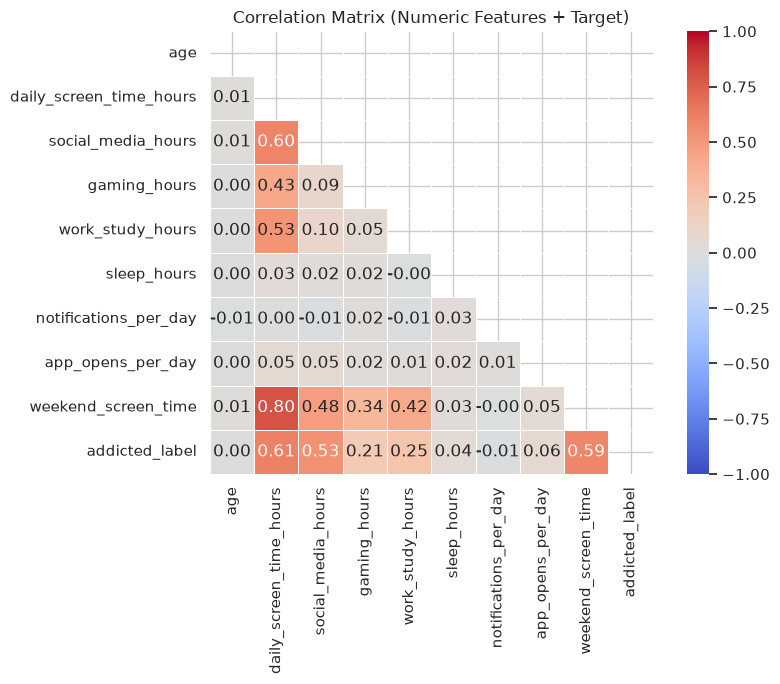

In [21]:
corr_cols = numeric_cols + [TARGET]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix (Numeric Features + Target)")
plt.tight_layout()
plt.show()


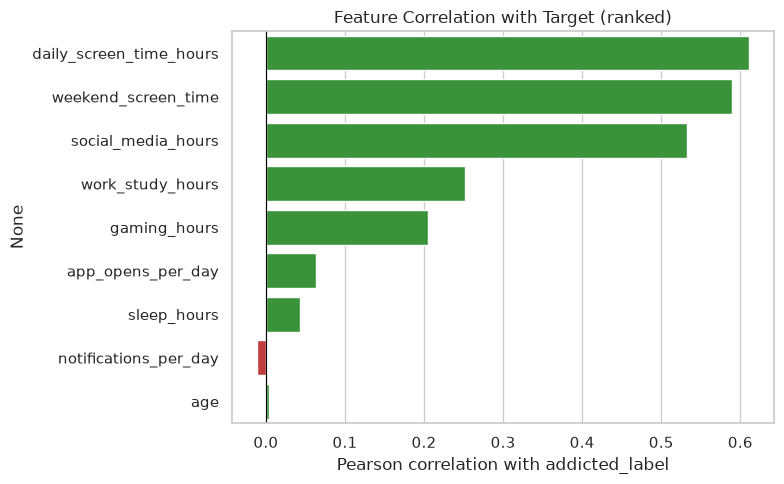

daily_screen_time_hours    0.611398
weekend_screen_time        0.589903
social_media_hours         0.532409
work_study_hours           0.251416
gaming_hours               0.205283
app_opens_per_day          0.063482
sleep_hours                0.042545
notifications_per_day     -0.011583
age                        0.004043
Name: addicted_label, dtype: float64

In [22]:
# Rank features purely by |correlation| with the target
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#d62728" if v < 0 else "#2ca02c" for v in target_corr.values]
sns.barplot(x=target_corr.values, y=target_corr.index, palette=colors, ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson correlation with addicted_label")
ax.set_title("Feature Correlation with Target (ranked)")
plt.tight_layout()
plt.show()

target_corr


In [23]:
# Highly correlated feature PAIRS (potential redundancy / multicollinearity)
corr_pairs = corr_matrix.drop(columns=[TARGET]).drop(index=[TARGET]).abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1].sort_values(ascending=False)
corr_pairs = corr_pairs[~corr_pairs.index.duplicated()]  # de-dup symmetric pairs
top_pairs = corr_pairs.head(10)
top_pairs


weekend_screen_time      daily_screen_time_hours    0.800061
daily_screen_time_hours  weekend_screen_time        0.800061
                         social_media_hours         0.595578
social_media_hours       daily_screen_time_hours    0.595578
daily_screen_time_hours  work_study_hours           0.525948
work_study_hours         daily_screen_time_hours    0.525948
social_media_hours       weekend_screen_time        0.478053
weekend_screen_time      social_media_hours         0.478053
gaming_hours             daily_screen_time_hours    0.429343
daily_screen_time_hours  gaming_hours               0.429343
dtype: float64

**Modeling implication:** any pair above roughly |r| > 0.7-0.8 is a multicollinearity
candidate — consider dropping one, combining them (e.g. a ratio or sum), or using
regularization (Ridge/Lasso) or tree-based models that are robust to it.

## 11. Numeric Features vs. Target (Distribution Split by Class)

Side-by-side boxplots/violins split by `addicted_label` show whether a feature's distribution
actually *shifts* between classes — the clearest visual signal of predictive power, beyond a
single correlation number (captures non-linear separation too).

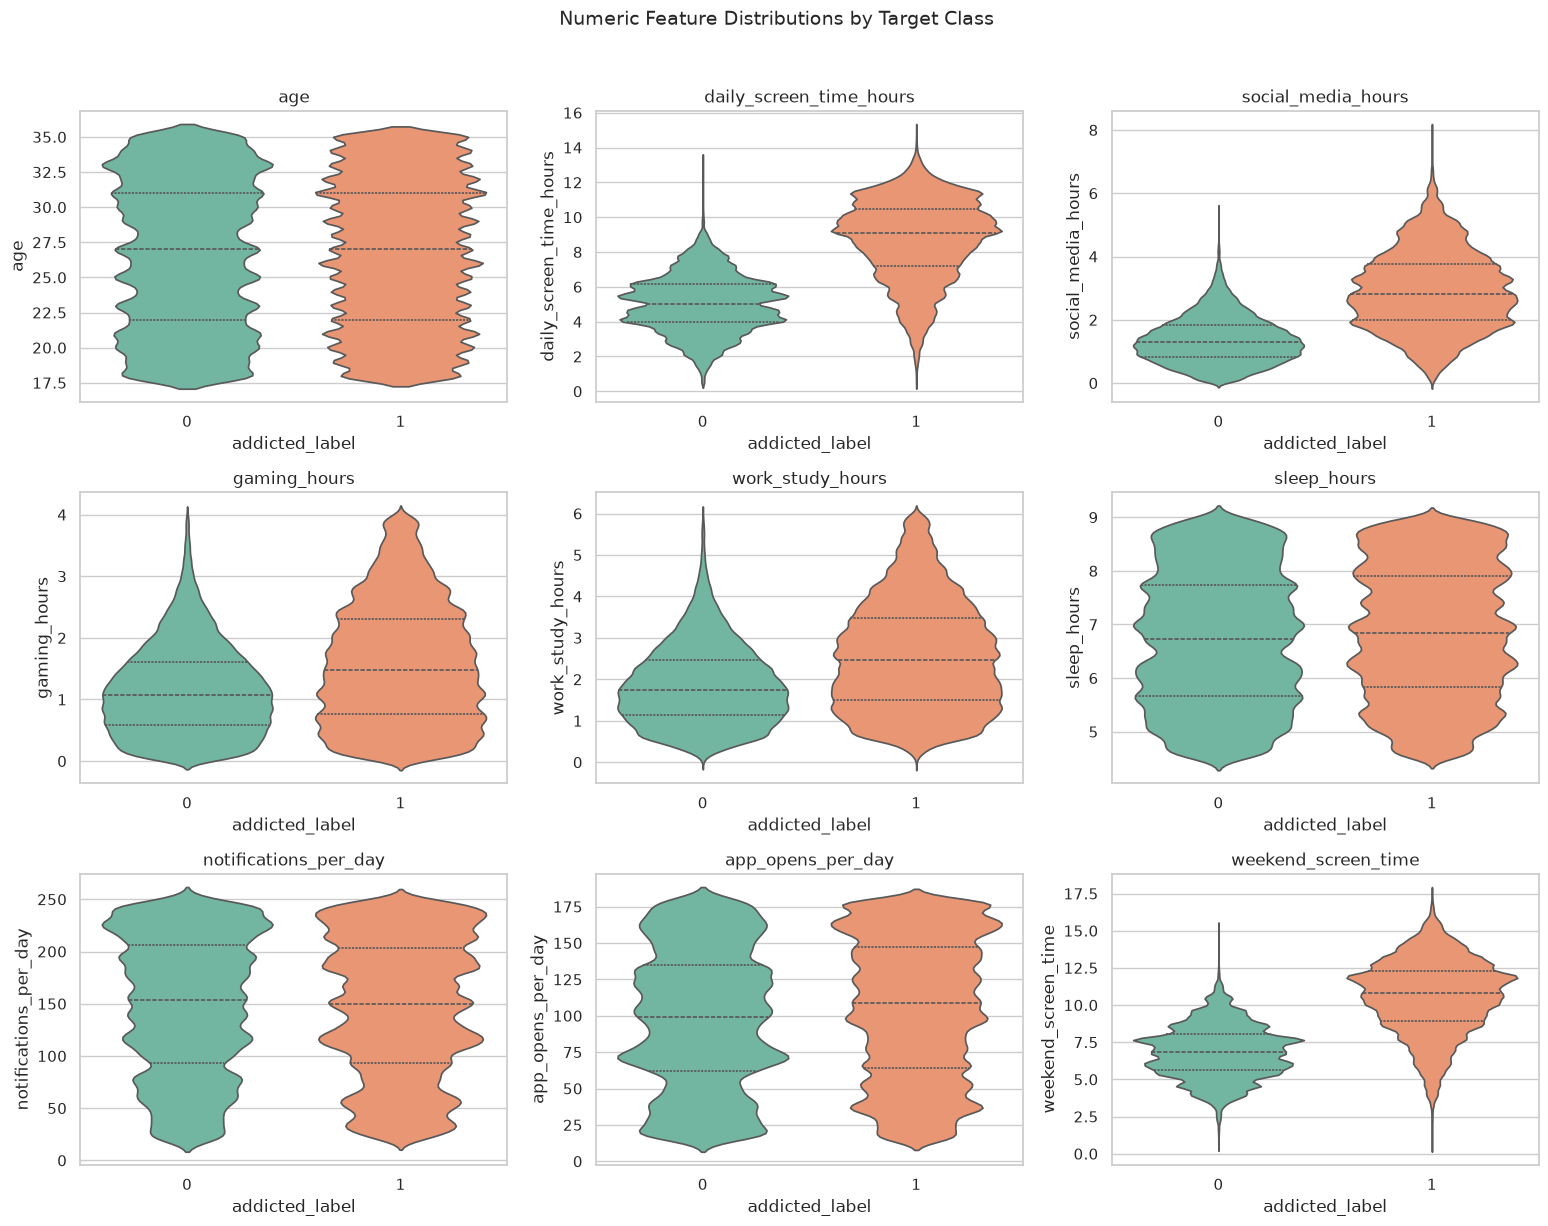

In [24]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(numeric_cols):
    sns.violinplot(x=df[TARGET], y=df[col], ax=axes[i], palette="Set2", inner="quartile")
    axes[i].set_title(col)
    axes[i].set_xlabel("addicted_label")

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Numeric Feature Distributions by Target Class", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


In [25]:
# Point-biserial correlation + group means/medians — a compact numeric summary
# to accompany the plots above.
rows = []
for col in numeric_cols:
    valid = df[[col, TARGET]].dropna()
    if valid[col].nunique() > 1:
        r, p = stats.pointbiserialr(valid[TARGET], valid[col])
    else:
        r, p = np.nan, np.nan
    rows.append({
        "feature": col,
        "point_biserial_r": r,
        "p_value": p,
        "mean_not_addicted": df.loc[df[TARGET] == 0, col].mean(),
        "mean_addicted": df.loc[df[TARGET] == 1, col].mean(),
    })
pb_summary = pd.DataFrame(rows).sort_values("point_biserial_r", key=lambda s: s.abs(), ascending=False)
pb_summary


,feature,point_biserial_r,p_value,mean_not_addicted,mean_addicted
1,daily_screen_time_hours,0.611398,0.000000e+00,5.042929,8.706523
8,weekend_screen_time,0.589903,0.000000e+00,6.848920,10.558729
2,social_media_hours,0.532409,0.000000e+00,1.376144,2.919495
4,work_study_hours,0.251416,0.000000e+00,1.872582,2.569566
3,gaming_hours,0.205283,0.000000e+00,1.159677,1.582119
7,app_opens_per_day,0.063482,0.000000e+00,97.871440,104.592844
5,sleep_hours,0.042545,7.511914e-257,6.722321,6.837970
6,notifications_per_day,-0.011583,5.768490e-20,147.087661,145.406142
0,age,0.004043,9.982787e-04,26.582864,26.628749


## 12. Pairwise Relationships Between Top Features

A pairplot of the features most correlated with the target, colored by class, to visually check
for separable clusters or non-linear boundaries that a single correlation coefficient would
miss.

In [26]:
top_features = target_corr.head(5).index.tolist()
plot_df = df[top_features + [TARGET]].dropna().copy()
plot_df[TARGET] = plot_df[TARGET].astype("category")

if len(plot_df) >= 3:
    g = sns.pairplot(plot_df, hue=TARGET, palette="Set1", diag_kind="kde",
                      plot_kws={"alpha": 0.7, "s": 40})
    g.fig.suptitle("Pairwise Relationships (Top Correlated Features)", y=1.02)
    plt.show()
else:
    print("Not enough complete rows to draw a pairplot yet — revisit with the full dataset.")


KeyboardInterrupt: 

## 13. Candidate Engineered Features

Based on the patterns above, these derived features are worth testing in the model. We compute
them here and immediately check their relationship with the target, the same way we did for the
raw features.

- `unaccounted_screen_time` = `daily_screen_time_hours` − (`social_media_hours` + `gaming_hours` + `work_study_hours`) — time spent on activities not itemized (messaging, browsing, video, calls).
- `weekend_weekday_diff` = `weekend_screen_time` − `daily_screen_time_hours` — behavior shift on weekends; a large positive gap may indicate compulsive weekend use.
- `notifications_per_app_open` = `notifications_per_day` / `app_opens_per_day` — how "reactive" usage is (opening the app because of a notification) vs. self-initiated.
- `sleep_deficit` = 8 − `sleep_hours` — hours short of a common recommended baseline; screen use displacing sleep is a classic addiction marker.
- `social_gaming_ratio` = `social_media_hours` / (`gaming_hours` + 0.01) — which type of usage dominates.
- `screen_to_work_ratio` = `daily_screen_time_hours` / (`work_study_hours` + 0.01) — leisure screen time relative to productive time.
- `stress_level_ordinal` = `stress_level` mapped Low=0, Medium=1, High=2 — makes the natural ordering usable by models that don't automatically infer it from one-hot columns.


In [30]:
df_fe = df.copy()

df_fe["unaccounted_screen_time"] = df_fe["daily_screen_time_hours"] - df_fe[sub_components].sum(axis=1, skipna=True)
df_fe["weekend_weekday_diff"] = df_fe["weekend_screen_time"] - df_fe["daily_screen_time_hours"]
df_fe["notifications_per_app_open"] = df_fe["notifications_per_day"] / df_fe["app_opens_per_day"].replace(0, np.nan)
df_fe["sleep_deficit"] = 8 - df_fe["sleep_hours"]
df_fe["social_gaming_ratio"] = df_fe["social_media_hours"] / (df_fe["gaming_hours"] + 0.01)
df_fe["screen_to_work_ratio"] = df_fe["daily_screen_time_hours"] / (df_fe["work_study_hours"] + 0.01)

####### MY WORK ########

df_fe["social_media_ratio"] = df_fe["social_media_hours"] / (df_fe["daily_screen_time_hours"] + 0.01)
df_fe["portion_of_day_on_screen"] = df_fe["daily_screen_time_hours"] / (24 - df_fe["sleep_hours"])

########################

stress_map = {"Low": 0, "Medium": 1, "High": 2}
df_fe["stress_level_ordinal"] = df_fe["stress_level"].map(stress_map)

engineered_cols = ["unaccounted_screen_time", "weekend_weekday_diff", "notifications_per_app_open",
                    "sleep_deficit", "social_gaming_ratio", "screen_to_work_ratio", "stress_level_ordinal", 
                    "social_media_ratio", "portion_of_day_on_screen"]
df_fe[engineered_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
unaccounted_screen_time,595515.0,2.115226,2.141970,0.000000,0.560000,1.130000,3.170000,14.810000
weekend_weekday_diff,517906.0,1.837633,1.766462,-7.910000,0.630000,1.840000,3.030000,11.490000
notifications_per_app_open,568082.0,2.061305,2.045609,0.111111,0.895652,1.400000,2.410256,16.666667
sleep_deficit,646889.0,1.195666,1.234512,-1.000000,0.130000,1.200000,2.220000,3.500000
social_gaming_ratio,484281.0,3.944821,9.516521,0.000000,0.980583,1.666667,3.215686,505.000000
screen_to_work_ratio,553430.0,4.098230,2.804087,1.074468,2.414773,3.093750,4.633981,50.000000
stress_level_ordinal,636221.0,1.020575,0.820568,0.000000,0.000000,1.000000,2.000000,2.000000
social_media_ratio,502260.0,0.326336,0.134186,0.000000,0.230539,0.329799,0.417219,0.883969
portion_of_day_on_screen,559350.0,0.446800,0.163338,0.025667,0.315646,0.451197,0.577791,0.789141


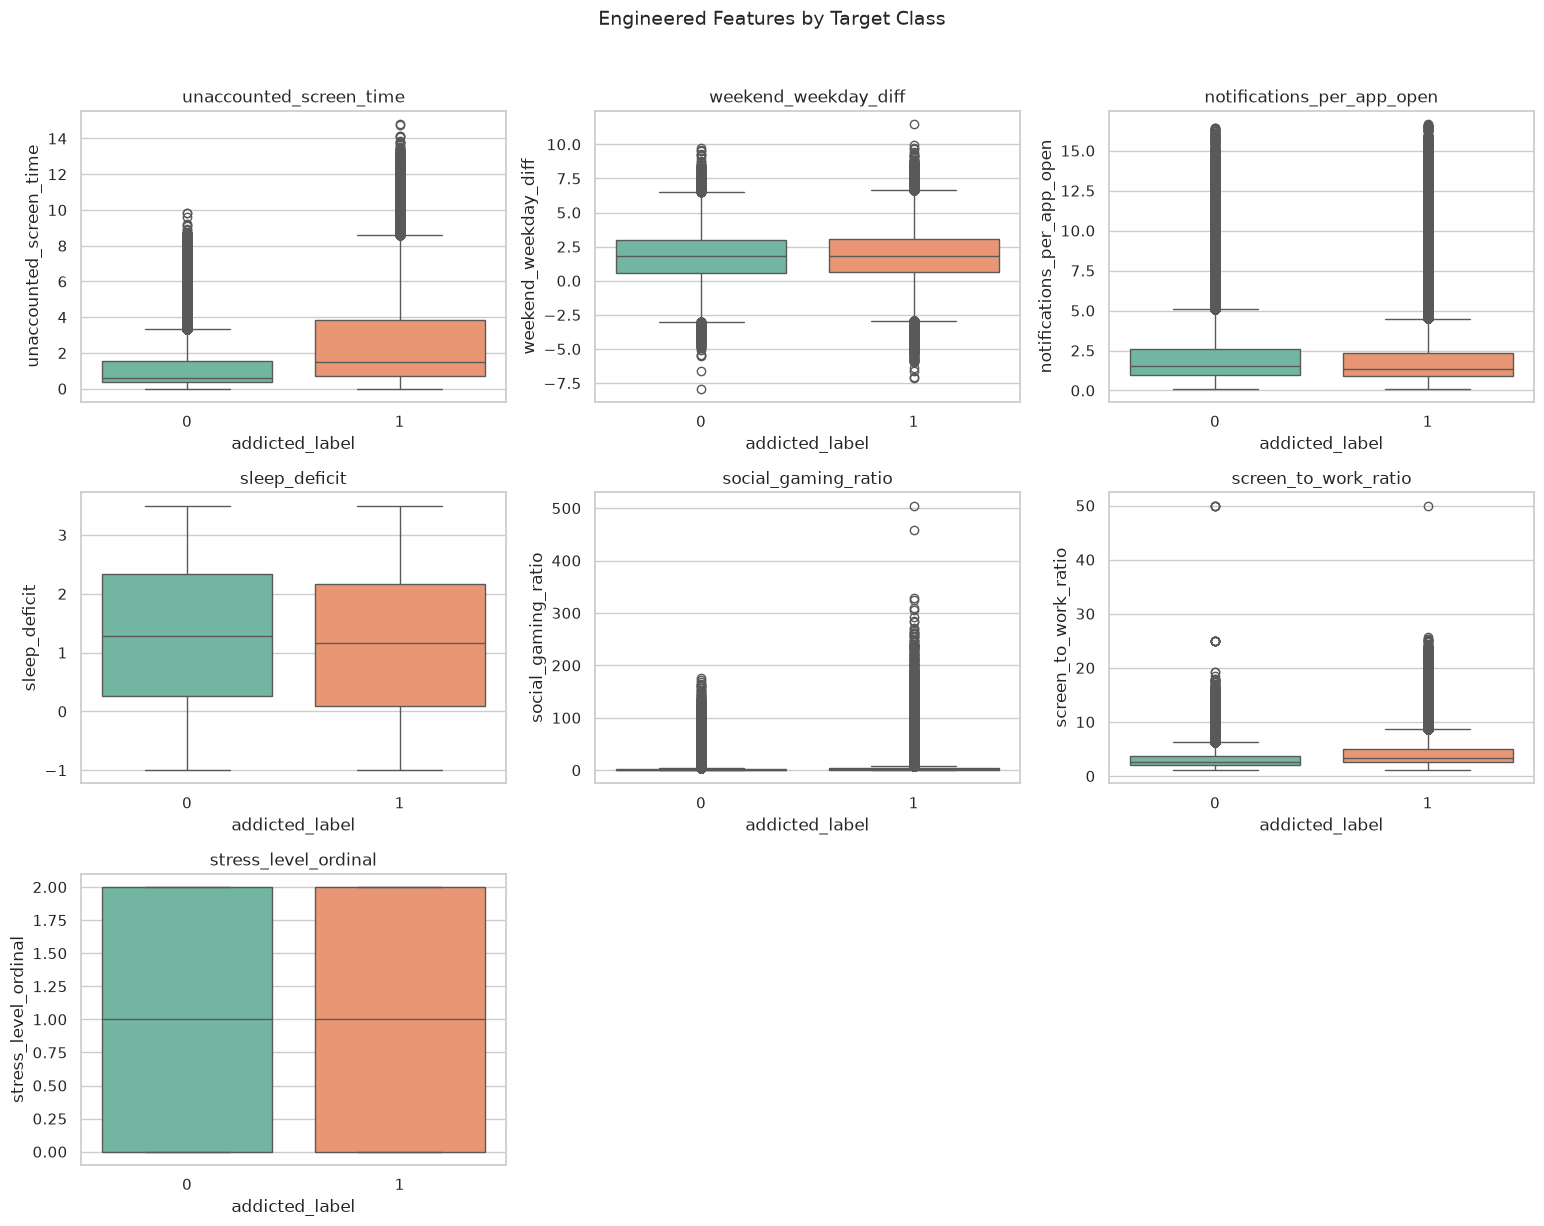

In [ ]:
n_cols = 3
n_rows = int(np.ceil(len(engineered_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(engineered_cols):
    valid = df_fe[[col, TARGET]].dropna()
    if valid[col].nunique() > 1:
        sns.boxplot(x=valid[TARGET], y=valid[col], ax=axes[i], palette="Set2")
    axes[i].set_title(col)
    axes[i].set_xlabel("addicted_label")

for j in range(len(engineered_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Engineered Features by Target Class", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


In [31]:
rows = []
for col in engineered_cols:
    valid = df_fe[[col, TARGET]].dropna()
    if valid[col].nunique() > 1 and len(valid) > 2:
        r, p = stats.pointbiserialr(valid[TARGET], valid[col])
    else:
        r, p = np.nan, np.nan
    rows.append({"engineered_feature": col, "point_biserial_r": r, "p_value": p})
pd.DataFrame(rows).sort_values("point_biserial_r", key=lambda s: s.abs(), ascending=False)


,engineered_feature,point_biserial_r,p_value
8,portion_of_day_on_screen,0.602271,0.000000e+00
0,unaccounted_screen_time,0.287947,0.000000e+00
7,social_media_ratio,0.242062,0.000000e+00
5,screen_to_work_ratio,0.177351,0.000000e+00
4,social_gaming_ratio,0.073673,0.000000e+00
2,notifications_per_app_open,-0.043974,4.096199e-241
3,sleep_deficit,-0.042545,7.511914e-257
1,weekend_weekday_diff,0.013584,1.424166e-22
6,stress_level_ordinal,0.000347,7.821861e-01


## 14. Age vs. Target

Age effects are often non-linear (e.g. risk peaks in a specific age band rather than increasing
/ decreasing monotonically), so besides correlation we also bin age and look at the addiction
rate per bin.

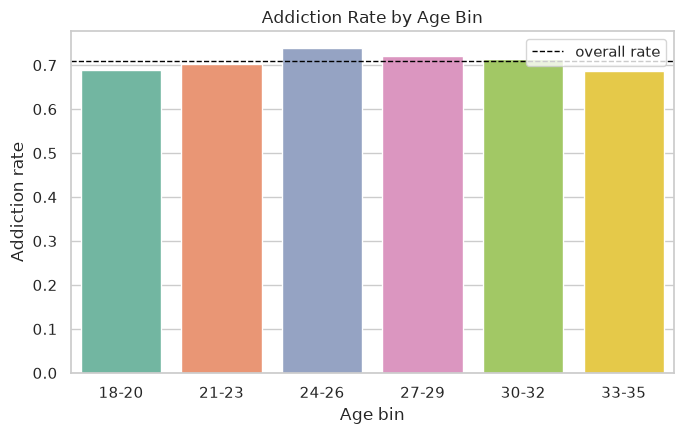

In [29]:
if "age" in df.columns:
    age_bins = pd.cut(df["age"], bins=[17, 20, 23, 26, 29, 32, 35, 100],
                       labels=["18-20", "21-23", "24-26", "27-29", "30-32", "33-35", "36+"])
    rate_by_age_bin = df.groupby(age_bins)[TARGET].mean()

    fig, ax = plt.subplots(figsize=(7, 4.5))
    sns.barplot(x=rate_by_age_bin.index.astype(str), y=rate_by_age_bin.values, palette="Set2", ax=ax)
    ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1, label="overall rate")
    ax.set_ylabel("Addiction rate")
    ax.set_xlabel("Age bin")
    ax.set_title("Addiction Rate by Age Bin")
    ax.legend()
    plt.tight_layout()
    plt.show()


## 15. Summary of Insights & Recommended Next Steps

**Fill this in from the outputs above once run on the full dataset** — with only 7 demo rows the
statistics here aren't reliable, but this is the checklist to work through:

**Data quality**
- Note which columns had the highest missing-value rates from Section 4, and whether
  missingness correlated with the target — if so, add `<col>_was_missing` indicator features.
- Review the outlier table (Section 7): decide per-column whether extreme values are genuine
  heavy-usage behavior (keep, maybe even flag with an `is_heavy_user` feature) or likely data
  errors (cap/winsorize or drop).

**Target & class balance**
- Record the class split from Section 5. If imbalanced, plan for `class_weight="balanced"`,
  stratified CV splits, and prioritize ROC-AUC / F1 over accuracy.

**Strongest raw predictors**
- List the top features by `|point_biserial_r|` from Section 11's `pb_summary` table, and the
  categorical features with the largest addiction-rate spread / significant chi-square p-value
  from Section 9.

**Engineered features worth keeping**
- From Section 13, keep engineered features whose `point_biserial_r` with the target is stronger
  than their raw source columns (that's the sign the transformation added real signal, not just
  redundancy).

**Multicollinearity**
- From Section 10's top-pairs table, decide which of any highly correlated raw feature pairs to
  drop, combine, or leave to a regularized/tree-based model to handle.

**Preprocessing pipeline to build next**
1. Impute missing numeric values (median, or group-wise median by target-relevant category) —
   plus `_was_missing` indicators where Section 4 showed a target relationship.
2. Encode `gender` with one-hot, `stress_level` with the ordinal mapping used in Section 13,
   and `academic_work_impact` as binary (with a missing-value strategy for its NaNs).
3. Add the engineered features from Section 13 that showed signal.
4. Scale numeric features (StandardScaler, or RobustScaler if Section 7 showed heavy outliers).
5. Baseline a simple model first (Logistic Regression) for interpretability, then compare
   against tree-based models (Random Forest / Gradient Boosting) which handle non-linearity,
   outliers, and multicollinearity more gracefully — use the same stratified CV split for a fair
   comparison.
